In [1]:
import matplotlib.pyplot as plt
import os

In [2]:
import numpy as np
x = np.load(r"C:\MTP\new_model\features\spectrogram\atlantic_spotted_dolphin\6102500B_mel.npy")
print(x.shape)

(1, 128, 145)


In [3]:
import numpy as np
x = np.load(r"C:\MTP\new_model\features\spectrogram\atlantic_spotted_dolphin\6102500B_mel.npy")
print(x)

[[[-100.       -100.       -100.       ... -100.       -100.
   -100.      ]
  [ -15.651017  -15.454312  -15.356964 ...  -15.350657  -15.456282
    -15.44253 ]
  [ -10.663559  -10.466853  -10.369507 ...  -10.363199  -10.468824
    -10.455073]
  ...
  [ -24.395977  -28.81283   -27.353329 ...  -24.798092  -27.650242
    -25.354967]
  [ -24.647875  -24.060188  -24.321451 ...  -23.73005   -24.73791
    -22.994097]
  [ -21.503963  -22.11667   -21.933964 ...  -21.130754  -22.513048
    -20.625765]]]


In [5]:
import numpy as np
x = np.load(r"C:\MTP\new_model\transformerencoder_patch_based_model_spec\results_5folds_model_2\fold_CM\fold_0_confusion.npy")
print(x)

[[ 48   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   1   0   0   0   0   0]
 [  0  15   1   0  11   0   0   0   0   0   0   0   0   0   0   2   0   0
    0   0   0   0   0   0   0]
 [  0   2  23   1   0   0   0   0   0   0   0   3   0   0   0   0   0   0
    0   0   0   0   1   0   0]
 [  0   0   0  34   0   0   0   0   0   1   0   0   0   0   1   0   0   0
    0   1   0   0   0   0   0]
 [  0  10   0   0  68   0   0   0   0   0   0   4   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   0   0   2   0  46   1   0   0   0   0   0   0   4   0   0   0   0
    0   2   1   6   0   0   3]
 [  0   0   0   3   0   0 157   1   0   2   0   0   5   3   0   0   0   0
    0   2   0   4   0   0   0]
 [  0   0   0   0   0   0   0  96   0   0   2   0   0   0   0   0   0   0
    0   0   0   0   0   3   1]
 [  0   9   1   1   4   0   0   0  88   0   0   6   0   0   0   0   0   0
    0   2   0   0   3   0   2]
 [  0   0   0   4   0   0   0   0   0  35   0   0   0  

In [6]:
val_class_counts = x.sum(axis=1)

In [7]:
print("\nValidation samples per class:")
for i, count in enumerate(val_class_counts):
    print(f"Class {i}: {count}")


Validation samples per class:
Class 0: 49
Class 1: 29
Class 2: 30
Class 3: 37
Class 4: 82
Class 5: 65
Class 6: 177
Class 7: 102
Class 8: 116
Class 9: 40
Class 10: 72
Class 11: 121
Class 12: 529
Class 13: 243
Class 14: 32
Class 15: 97
Class 16: 207
Class 17: 30
Class 18: 124
Class 19: 284
Class 20: 105
Class 21: 136
Class 22: 24
Class 23: 39
Class 24: 112


In [8]:
sum(val_class_counts)

2882

In [9]:
train_dist={}
cl=0
base_path=r"C:\MTP\new_model\features\spectrogram"
for i in os.listdir(base_path):
    j=os.path.join(base_path,i)
    train_dist[cl]=len(os.listdir(j))
    cl+=1
print(train_dist)  

{0: 244, 1: 142, 2: 150, 3: 189, 4: 407, 5: 328, 6: 884, 7: 508, 8: 583, 9: 199, 10: 359, 11: 604, 12: 2647, 13: 1213, 14: 161, 15: 486, 16: 1034, 17: 149, 18: 619, 19: 1421, 20: 524, 21: 681, 22: 122, 23: 196, 24: 560}


In [14]:
sum(train_dist.values())

14410

In [15]:
14410-2882

11528

In [16]:
data_dir = r"C:\MTP\new_model\features\spectrogram"

class_names = sorted(os.listdir(data_dir))

class_to_idx = {name: i for i, name in enumerate(class_names)}

idx_to_class = {i: name for name, i in class_to_idx.items()}

<BarContainer object of 25 artists>

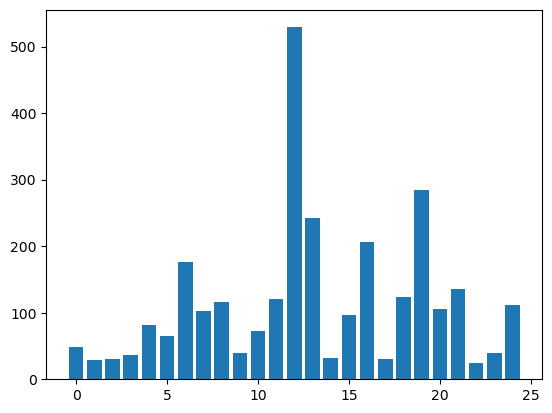

In [10]:
plt.bar([i for i in range(0,25)],val_class_counts)

In [45]:
arr_train_dist=[]
for i in range(0,len(train_dist)):
    arr_train_dist.append(train_dist[i])
arr_train_dist=np.array(arr_train_dist)

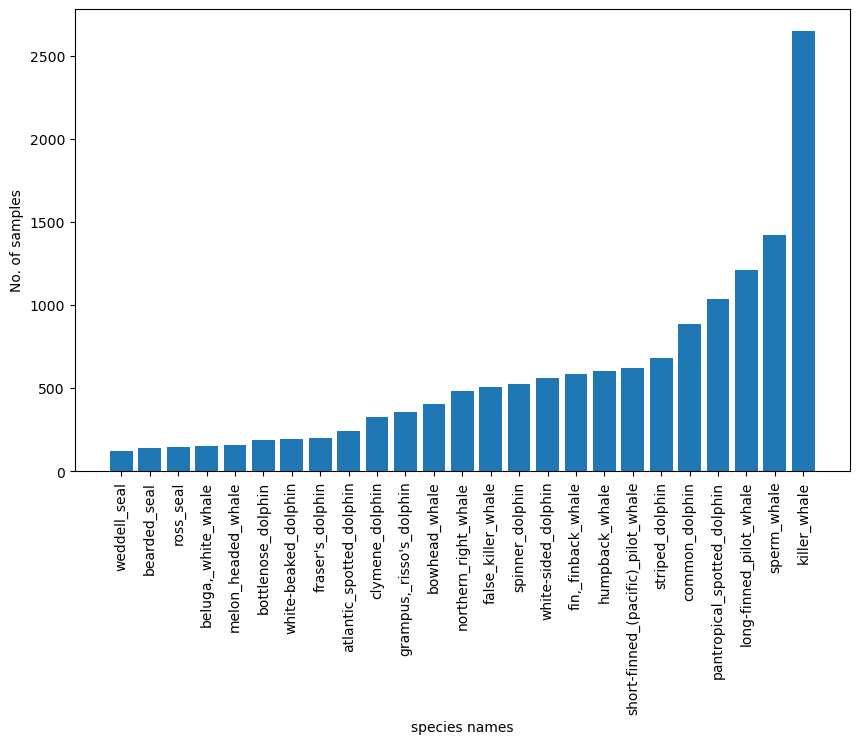

In [60]:

idx = np.argsort(arr_train_dist)

sorted_arr_train_dist = arr_train_dist[idx]
sorted_names = np.array(class_names)[idx]

plt.figure(figsize=(10,6))
plt.bar(sorted_names,sorted_arr_train_dist)

plt.xlabel("species names")
plt.ylabel("No. of samples")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

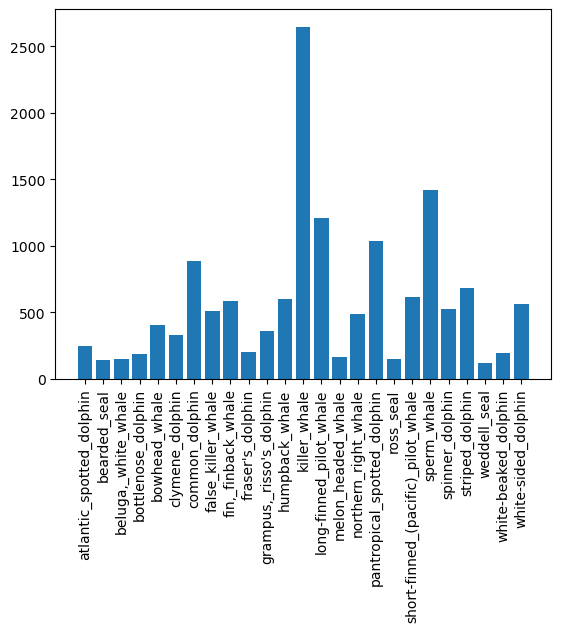

In [51]:
plt.bar(class_names,train_dist.values())
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()